# Embedding Evaluation — COLIPRI (Zero-Shot)

Encoder-agnostic evaluation of any `.npz` conforming to the standard embedding interface.
Runs the full T1–T3 battery and produces inline figures for visual inspection.

**Change `NPZ_PATH` below to evaluate a different encoder.**

In [16]:
NPZ_PATH   = "/data1/Processed_NIfTI_Test/embeddings/raddino/raddino_embeddings.npz"
OUTPUT_DIR = "/data1/Processed_NIfTI_Test/embeddings/raddino"
ENCODER_NAME = "RAD-DINO"

In [17]:
import os, warnings
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, adjusted_rand_score, f1_score,
    normalized_mutual_info_score, roc_auc_score, silhouette_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder, normalize
import umap

os.makedirs(OUTPUT_DIR, exist_ok=True)
plots_dir = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(plots_dir, exist_ok=True)

WEEK_ORDER  = ["Week 12", "Week 15", "Week 18", "Week 20"]
WEEK_COLORS = {
    "Week 12": "#2196F3",
    "Week 15": "#4CAF50",
    "Week 18": "#FF9800",
    "Week 20": "#F44336",
}
print('Imports OK')

Imports OK


## Load Embeddings

In [18]:
data = np.load(NPZ_PATH, allow_pickle=True)
embs        = data["embeddings"].astype(np.float32)
subject_ids = data["subject_ids"].astype(str)
weeks       = data["weeks"].astype(str)
modalities  = data["modalities"].astype(str)
paths       = data["paths"].astype(str)

# Parse cohort/genotype from mouse_id (e.g. "NaF_WT_03" → cohort=NaF, geno=WT)
cohorts   = np.array([s.split('_')[0] for s in subject_ids])
genotypes = np.array([s.split('_')[1] for s in subject_ids])

print(f"Embeddings : {embs.shape}")
print(f"Subjects   : {len(set(subject_ids))} unique mice")
print(f"Weeks      : {sorted(set(weeks))}")
print(f"Cohorts    : {sorted(set(cohorts))}")
print(f"Genotypes  : {sorted(set(genotypes))}")

Embeddings : (229, 768)
Subjects   : 78 unique mice
Weeks      : [np.str_('Week 12'), np.str_('Week 15'), np.str_('Week 18'), np.str_('Week 20')]
Cohorts    : [np.str_('FDG'), np.str_('NaF')]
Genotypes  : [np.str_('KO'), np.str_('WT')]


## T1a — Dimensionality Reduction

t-SNE and UMAP projections coloured by week, cohort, and genotype.  
**Primary success criterion:** Week 12 and Week 20 clusters should visually separate.

In [19]:
perplexity = min(30, max(5, len(embs) // 4))
print(f"Running t-SNE (perplexity={perplexity}, n={len(embs)})...")
tsne_coords = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000).fit_transform(embs)

n_neighbors = min(15, max(2, len(embs) - 1))
print(f"Running UMAP (n_neighbors={n_neighbors})...")
umap_coords = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=42).fit_transform(embs)
print("Done.")

Running t-SNE (perplexity=30, n=229)...
Running UMAP (n_neighbors=15)...


/home/ryab/miniconda3/envs/vlm_env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


/tmp/ipykernel_2119074/3420420314.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, len(unique))


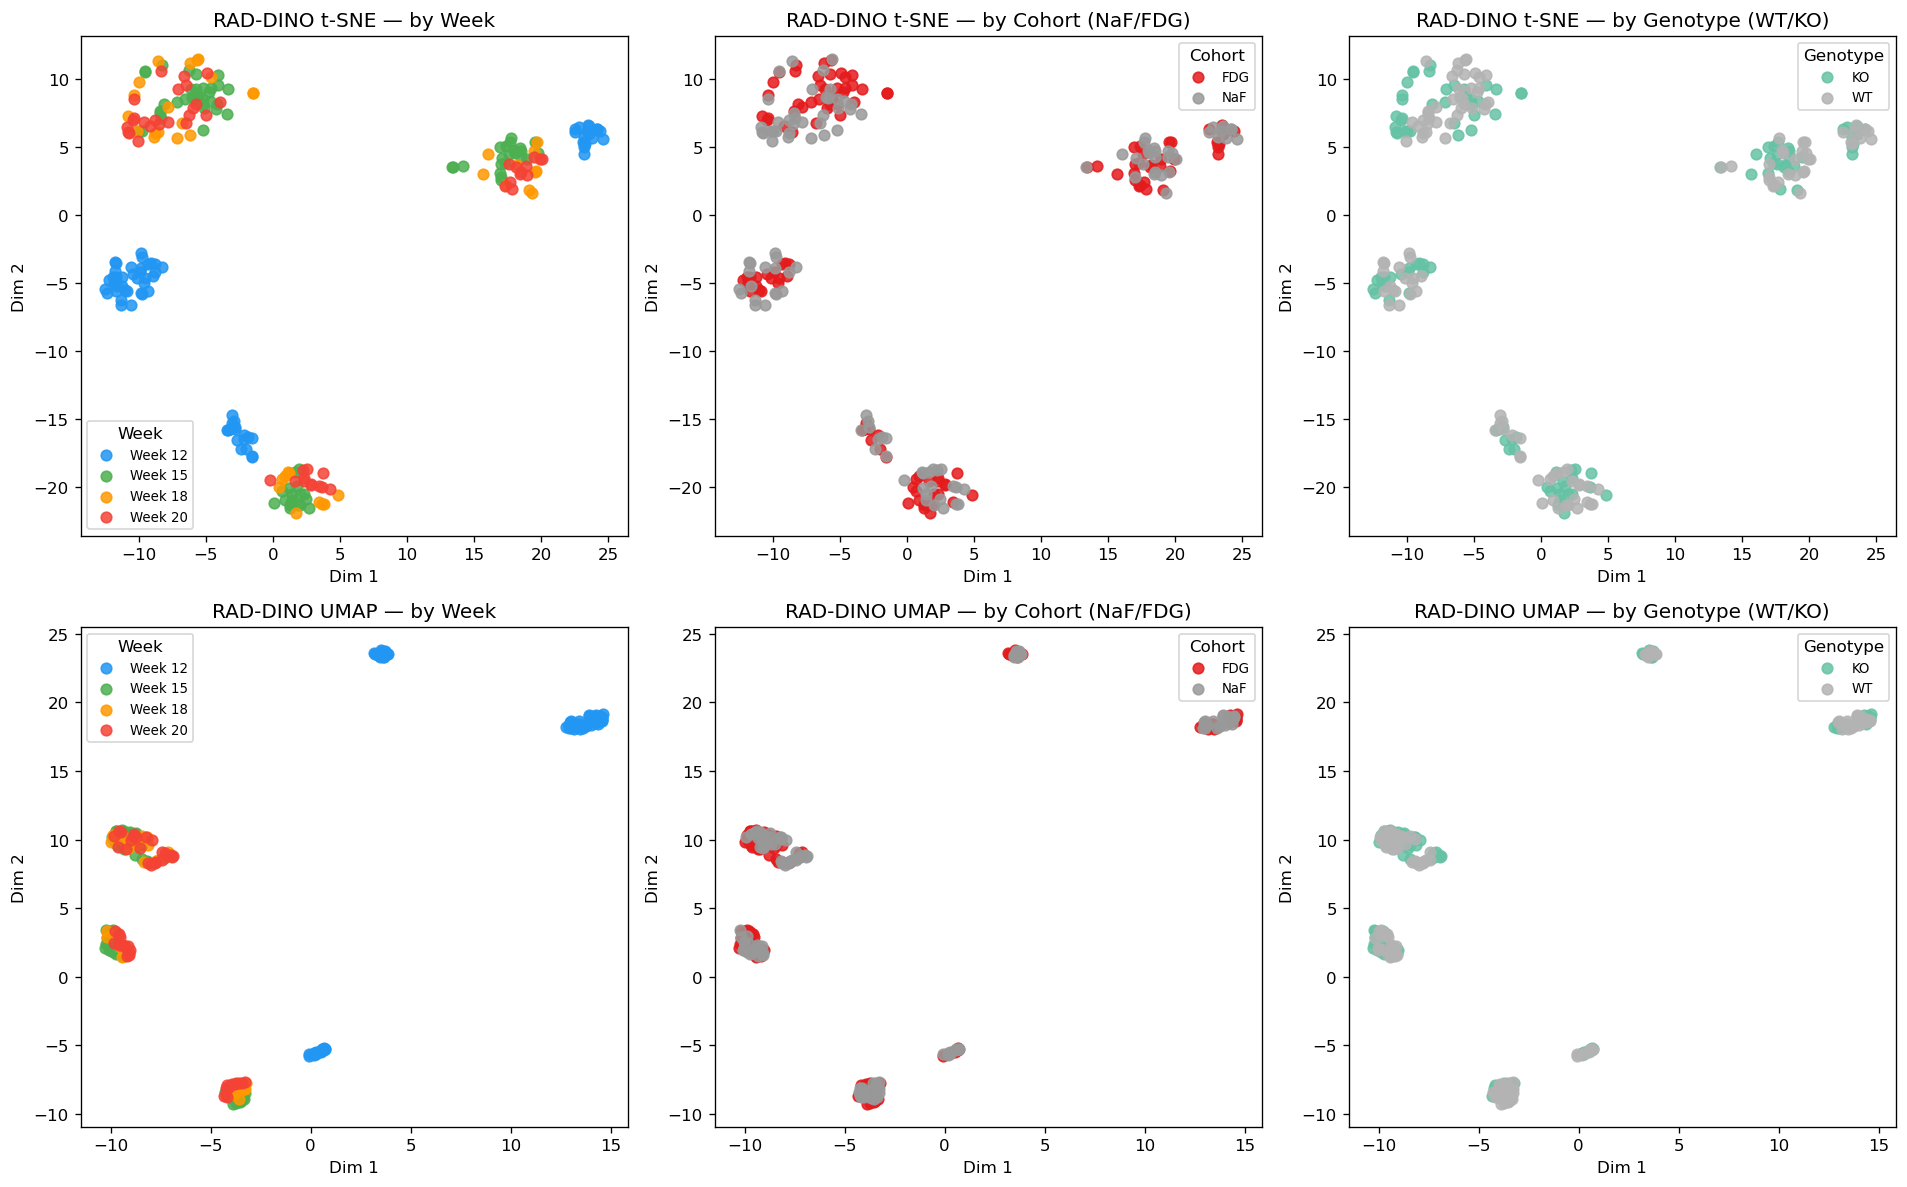

In [20]:
def scatter_by_week(coords, title, ax):
    for week in WEEK_ORDER:
        mask = weeks == week
        if mask.any():
            ax.scatter(coords[mask, 0], coords[mask, 1], label=week,
                       color=WEEK_COLORS[week], s=40, alpha=0.85)
    ax.legend(title="Week", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

def scatter_by_group(coords, labels, cmap_name, legend_title, title, ax):
    unique = sorted(set(labels))
    cmap = plt.cm.get_cmap(cmap_name, len(unique))
    for i, grp in enumerate(unique):
        mask = labels == grp
        ax.scatter(coords[mask, 0], coords[mask, 1], label=grp,
                   color=cmap(i), s=40, alpha=0.85)
    ax.legend(title=legend_title, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
scatter_by_week(tsne_coords, f"{ENCODER_NAME} t-SNE — by Week", axes[0, 0])
scatter_by_group(tsne_coords, cohorts,   "Set1",  "Cohort",   f"{ENCODER_NAME} t-SNE — by Cohort (NaF/FDG)", axes[0, 1])
scatter_by_group(tsne_coords, genotypes, "Set2",  "Genotype", f"{ENCODER_NAME} t-SNE — by Genotype (WT/KO)", axes[0, 2])
scatter_by_week(umap_coords, f"{ENCODER_NAME} UMAP — by Week", axes[1, 0])
scatter_by_group(umap_coords, cohorts,   "Set1",  "Cohort",   f"{ENCODER_NAME} UMAP — by Cohort (NaF/FDG)", axes[1, 1])
scatter_by_group(umap_coords, genotypes, "Set2",  "Genotype", f"{ENCODER_NAME} UMAP — by Genotype (WT/KO)", axes[1, 2])
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "t1a_dimred.png"), dpi=150, bbox_inches="tight")
plt.show()

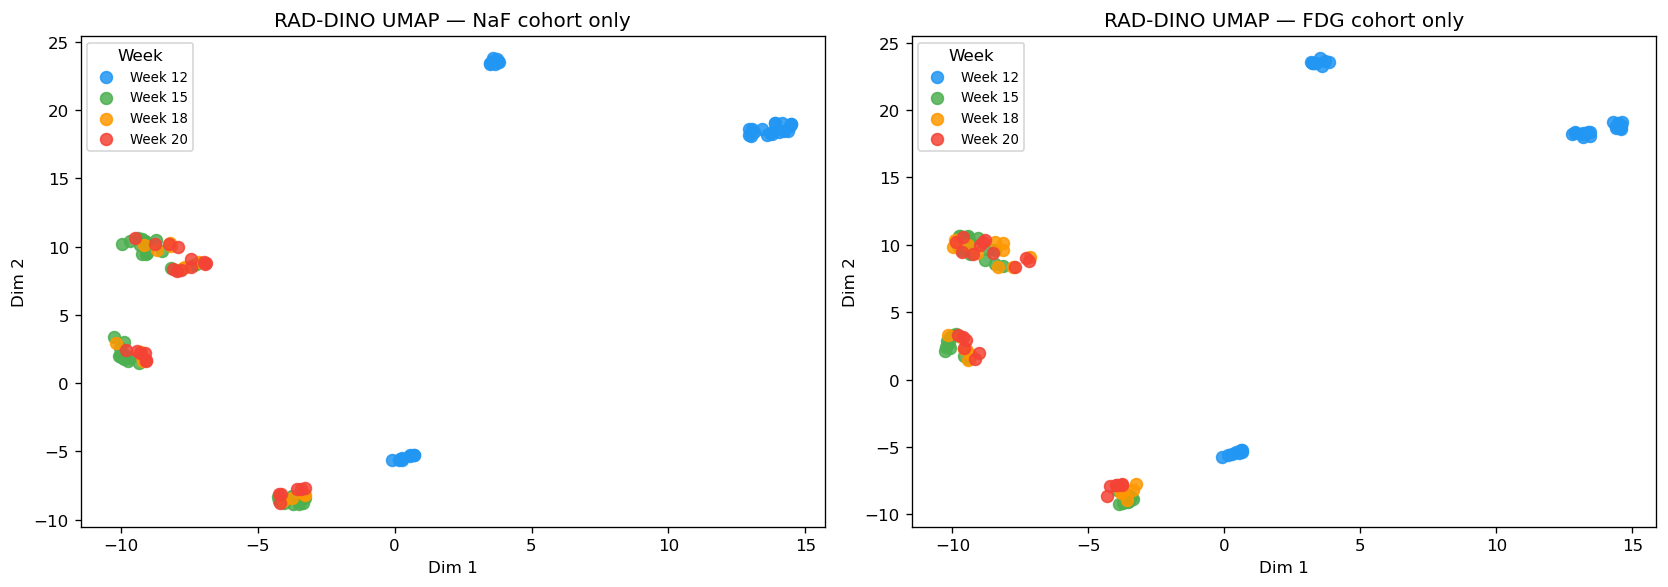

In [21]:
# Per-cohort UMAP side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cohort in zip(axes, ["NaF", "FDG"]):
    mask = cohorts == cohort
    for week in WEEK_ORDER:
        wm = mask & (weeks == week)
        if wm.any():
            ax.scatter(umap_coords[wm, 0], umap_coords[wm, 1],
                       label=week, color=WEEK_COLORS[week], s=50, alpha=0.85)
    ax.set_title(f"{ENCODER_NAME} UMAP — {cohort} cohort only")
    ax.legend(title="Week", fontsize=8)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "t1a_umap_per_cohort.png"), dpi=150, bbox_inches="tight")
plt.show()

## T1b — Unsupervised Cluster Alignment

k-means (k=4) cluster labels vs. true week labels.  
ARI and NMI: 0 = random, 1 = perfect.

In [22]:
week_labels_enc = LabelEncoder().fit_transform(weeks)
cluster_labels  = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(embs)

ari = adjusted_rand_score(week_labels_enc, cluster_labels)
nmi = normalized_mutual_info_score(week_labels_enc, cluster_labels)
print(f"T1b  ARI = {ari:.4f}  (0=random, 1=perfect)")
print(f"T1b  NMI = {nmi:.4f}  (0=random, 1=perfect)")

T1b  ARI = -0.0102  (0=random, 1=perfect)
T1b  NMI = 0.0129  (0=random, 1=perfect)


## T1c — Silhouette Score by Week

In [23]:
sil = silhouette_score(normalize(embs), week_labels_enc, metric="cosine")
print(f"T1c  Silhouette (cosine, by week) = {sil:.4f}  (>0 means week clusters are more cohesive than random)")

T1c  Silhouette (cosine, by week) = 0.0201  (>0 means week clusters are more cohesive than random)


## T1d — Within-Subject vs. Cross-Subject Cosine Similarity

Does the encoder preserve mouse identity across timepoints?  
Δ = intra − inter: positive means same-mouse scans are more similar than different-mouse scans.

T1d  Intra-subject cosine sim : 0.9750
T1d  Inter-subject cosine sim : 0.9695
T1d  Δ (intra − inter)        : 0.0055  (>0 = identity preserved)


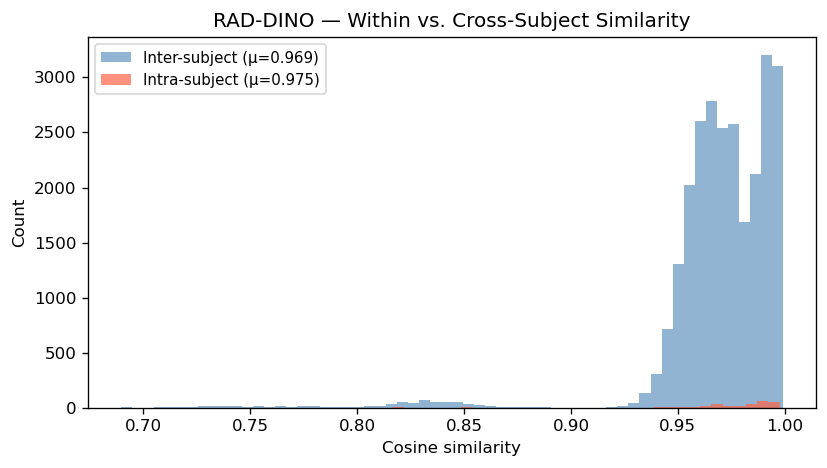

In [24]:
cos_sim = normalize(embs) @ normalize(embs).T
intra, inter = [], []
n = len(subject_ids)
for i in range(n):
    for j in range(i + 1, n):
        (intra if subject_ids[i] == subject_ids[j] else inter).append(cos_sim[i, j])

mean_intra = float(np.mean(intra))
mean_inter = float(np.mean(inter))
delta = mean_intra - mean_inter
print(f"T1d  Intra-subject cosine sim : {mean_intra:.4f}")
print(f"T1d  Inter-subject cosine sim : {mean_inter:.4f}")
print(f"T1d  Δ (intra − inter)        : {delta:.4f}  (>0 = identity preserved)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(inter, bins=60, alpha=0.6, label=f"Inter-subject (μ={mean_inter:.3f})", color="steelblue")
ax.hist(intra, bins=40, alpha=0.7, label=f"Intra-subject (μ={mean_intra:.3f})", color="tomato")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Count")
ax.set_title(f"{ENCODER_NAME} — Within vs. Cross-Subject Similarity")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "t1d_subject_similarity.png"), dpi=150, bbox_inches="tight")
plt.show()

## T2a — Week Classification (4-class, LOSO)

Logistic regression on frozen embeddings, Leave-One-Subject-Out CV.  
Chance = 0.25 (4 classes).

T2a  Week (4-class) accuracy = 0.8777  (chance = 0.25)
T2a  Week (4-class) macro-F1 = 0.8536


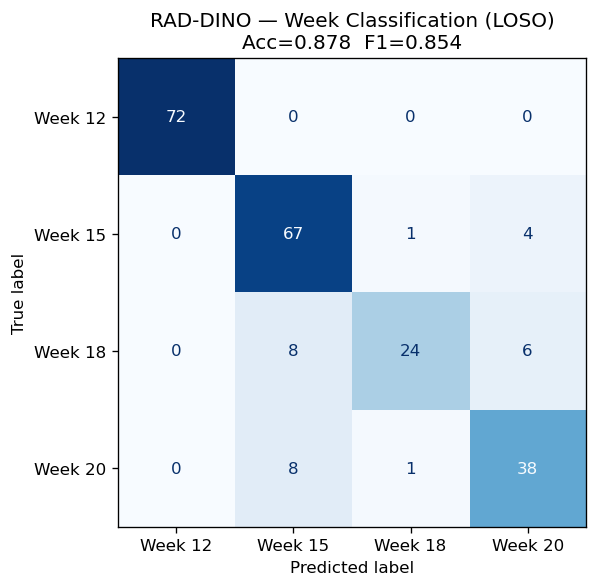

In [25]:
le = LabelEncoder()
y  = le.fit_transform(weeks)
loso = LeaveOneGroupOut()
y_true_all, y_pred_all = [], []

for train_idx, test_idx in loso.split(embs, y, groups=subject_ids):
    X_tr, X_te = embs[train_idx], embs[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    if len(set(y_tr)) < 2:
        continue
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42,
                             multi_class="multinomial", solver="lbfgs")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf.fit(X_tr, y_tr)
    y_true_all.extend(y_te)
    y_pred_all.extend(clf.predict(X_te))

t2a_acc = accuracy_score(y_true_all, y_pred_all)
t2a_f1  = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
print(f"T2a  Week (4-class) accuracy = {t2a_acc:.4f}  (chance = 0.25)")
print(f"T2a  Week (4-class) macro-F1 = {t2a_f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"{ENCODER_NAME} — Week Classification (LOSO)\nAcc={t2a_acc:.3f}  F1={t2a_f1:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "t2a_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## T2b — Early vs. Late (Week 12 vs. Week 20, LOSO)

Binary classification: can the encoder separate early-stage (Week 12) from late-stage (Week 20)?  
Chance = 0.50.

T2b  Early vs. Late accuracy = 1.0000  (chance = 0.50)
T2b  AUC-ROC                 = 1.0000


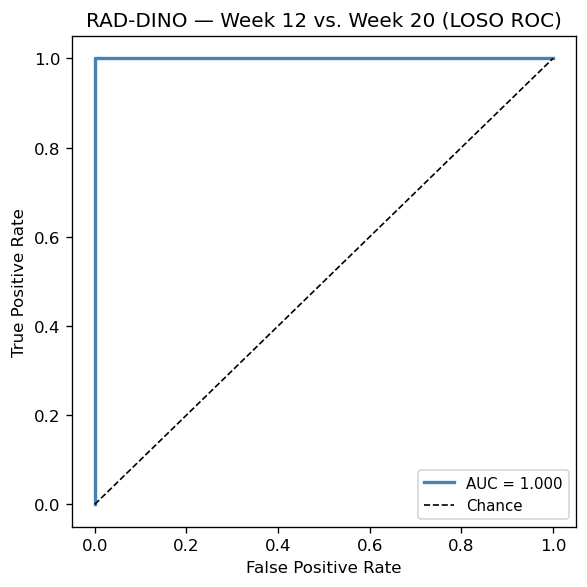

In [26]:
mask   = np.isin(weeks, ["Week 12", "Week 20"])
X_sub  = embs[mask]
y_sub  = (weeks[mask] == "Week 20").astype(int)
grp    = subject_ids[mask]

y_true_b, y_pred_b, y_prob_b = [], [], []
for train_idx, test_idx in loso.split(X_sub, y_sub, groups=grp):
    X_tr, X_te = X_sub[train_idx], X_sub[test_idx]
    y_tr, y_te = y_sub[train_idx], y_sub[test_idx]
    if len(set(y_tr)) < 2:
        continue
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver="lbfgs")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf.fit(X_tr, y_tr)
    y_true_b.extend(y_te)
    y_pred_b.extend(clf.predict(X_te))
    y_prob_b.extend(clf.predict_proba(X_te)[:, 1])

t2b_acc = accuracy_score(y_true_b, y_pred_b)
t2b_auc = roc_auc_score(y_true_b, y_prob_b) if len(set(y_true_b)) > 1 else float("nan")
print(f"T2b  Early vs. Late accuracy = {t2b_acc:.4f}  (chance = 0.50)")
print(f"T2b  AUC-ROC                 = {t2b_auc:.4f}")

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_true_b, y_prob_b)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {t2b_auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"{ENCODER_NAME} — Week 12 vs. Week 20 (LOSO ROC)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "t2b_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## T3a — Pairwise Temporal Ordering (LOSO)

For every same-mouse pair at different timepoints, can a linear classifier determine which scan came later?  
Chance = 0.50.

In [27]:
week_to_int = {w: i for i, w in enumerate(WEEK_ORDER)}
pair_diffs, pair_labels, pair_groups = [], [], []

for subj in sorted(set(subject_ids)):
    idx = np.where(subject_ids == subj)[0]
    tps = sorted([(week_to_int[weeks[i]], i) for i in idx if weeks[i] in week_to_int], key=lambda x: x[0])
    for (w1, i1), (w2, i2) in combinations(tps, 2):
        if w1 == w2:
            continue
        pair_diffs.append(embs[i2] - embs[i1]);  pair_labels.append(1); pair_groups.append(subj)
        pair_diffs.append(embs[i1] - embs[i2]);  pair_labels.append(0); pair_groups.append(subj)

X_pairs = np.array(pair_diffs, dtype=np.float32)
y_pairs = np.array(pair_labels)
g_pairs = np.array(pair_groups)

yt_t3a, yp_t3a = [], []
for train_idx, test_idx in loso.split(X_pairs, y_pairs, groups=g_pairs):
    if len(set(y_pairs[train_idx])) < 2:
        continue
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42, solver="lbfgs")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf.fit(X_pairs[train_idx], y_pairs[train_idx])
    yt_t3a.extend(y_pairs[test_idx])
    yp_t3a.extend(clf.predict(X_pairs[test_idx]))

t3a_acc = accuracy_score(yt_t3a, yp_t3a)
n_pairs = len(pair_diffs) // 2
print(f"T3a  Pairwise temporal ordering = {t3a_acc:.4f}  ({n_pairs} pairs, chance = 0.50)")

T3a  Pairwise temporal ordering = 0.9261  (257 pairs, chance = 0.50)


## T3b — Same-Subject Retrieval

For each scan, rank all others by cosine similarity. Does the nearest neighbour belong to the same mouse?

In [28]:
r1_hits, r3_hits, rr_list = [], [], []
for i in range(n):
    sims = cos_sim[i].copy()
    sims[i] = -np.inf
    ranked    = np.argsort(-sims)
    same_subj = subject_ids[ranked] == subject_ids[i]
    r1_hits.append(int(same_subj[0]))
    r3_hits.append(int(same_subj[:3].any()))
    first_hit = int(np.argmax(same_subj)) + 1 if same_subj.any() else n
    rr_list.append(1.0 / first_hit)

t3b_r1  = float(np.mean(r1_hits))
t3b_r3  = float(np.mean(r3_hits))
t3b_mrr = float(np.mean(rr_list))
print(f"T3b  Recall@1 = {t3b_r1:.4f}")
print(f"T3b  Recall@3 = {t3b_r3:.4f}")
print(f"T3b  MRR      = {t3b_mrr:.4f}")

T3b  Recall@1 = 0.0131
T3b  Recall@3 = 0.0568
T3b  MRR      = 0.0715


## T3c — Same-Week Retrieval (mAP@5)

In [29]:
def ap_at_k(relevant_mask, k):
    rel = relevant_mask[:k].astype(float)
    if rel.sum() == 0:
        return 0.0
    cum_hits = np.cumsum(rel)
    prec_at_hits = cum_hits / np.arange(1, len(rel) + 1)
    return float((prec_at_hits * rel).sum() / rel.sum())

k = 5
ap_list = []
for i in range(n):
    sims = cos_sim[i].copy(); sims[i] = -np.inf
    ranked = np.argsort(-sims)
    rel    = weeks[ranked] == weeks[i]
    ap_list.append(ap_at_k(rel, k))

t3c_map = float(np.mean(ap_list))
print(f"T3c  mAP@{k} = {t3c_map:.4f}  (fraction of top-{k} neighbours sharing the same week)")

T3c  mAP@5 = 0.8444  (fraction of top-5 neighbours sharing the same week)


## Summary Report

In [30]:
print("=" * 62)
print(f"  EMBEDDING EVALUATION — {ENCODER_NAME}")
print("=" * 62)
print(f"  Source : {NPZ_PATH}")
print(f"  Samples: {len(embs)}   Embedding dim: {embs.shape[1]}")
print()
print("  TIER 1 — UNSUPERVISED")
print("-" * 62)
print(f"  T1b  ARI  (k-means vs week)         : {ari:.4f}  [0=random, 1=perfect]")
print(f"  T1b  NMI  (k-means vs week)         : {nmi:.4f}  [0=random, 1=perfect]")
print(f"  T1c  Silhouette (cosine, by week)   : {sil:.4f}  [>0 = weeks cluster]")
print(f"  T1d  Intra-subject cosine sim       : {mean_intra:.4f}")
print(f"  T1d  Inter-subject cosine sim       : {mean_inter:.4f}")
print(f"  T1d  Δ (intra − inter)              : {delta:.4f}  [>0 = identity preserved]")
print()
print("  TIER 2 — LINEAR PROBE  (Leave-One-Subject-Out CV)")
print("-" * 62)
print(f"  T2a  Week (4-class) accuracy        : {t2a_acc:.4f}  (chance=0.25)")
print(f"  T2a  Week (4-class) macro-F1        : {t2a_f1:.4f}")
print(f"  T2b  Early vs Late accuracy         : {t2b_acc:.4f}  (chance=0.50)")
print(f"  T2b  Early vs Late AUC-ROC          : {t2b_auc:.4f}")
print()
print("  TIER 3 — LONGITUDINAL / RELATIONAL")
print("-" * 62)
print(f"  T3a  Pairwise temporal ordering     : {t3a_acc:.4f}  (chance=0.50)")
print(f"  T3b  Subject retrieval Recall@1     : {t3b_r1:.4f}")
print(f"  T3b  Subject retrieval Recall@3     : {t3b_r3:.4f}")
print(f"  T3b  Subject retrieval MRR          : {t3b_mrr:.4f}")
print(f"  T3c  Week retrieval mAP@5           : {t3c_map:.4f}")
print("=" * 62)

  EMBEDDING EVALUATION — RAD-DINO
  Source : /data1/Processed_NIfTI_Test/embeddings/raddino/raddino_embeddings.npz
  Samples: 229   Embedding dim: 768

  TIER 1 — UNSUPERVISED
--------------------------------------------------------------
  T1b  ARI  (k-means vs week)         : -0.0102  [0=random, 1=perfect]
  T1b  NMI  (k-means vs week)         : 0.0129  [0=random, 1=perfect]
  T1c  Silhouette (cosine, by week)   : 0.0201  [>0 = weeks cluster]
  T1d  Intra-subject cosine sim       : 0.9750
  T1d  Inter-subject cosine sim       : 0.9695
  T1d  Δ (intra − inter)              : 0.0055  [>0 = identity preserved]

  TIER 2 — LINEAR PROBE  (Leave-One-Subject-Out CV)
--------------------------------------------------------------
  T2a  Week (4-class) accuracy        : 0.8777  (chance=0.25)
  T2a  Week (4-class) macro-F1        : 0.8536
  T2b  Early vs Late accuracy         : 1.0000  (chance=0.50)
  T2b  Early vs Late AUC-ROC          : 1.0000

  TIER 3 — LONGITUDINAL / RELATIONAL
-----------